# 🔹Evaluation Metrics in Machine Learning

# 🔸Classification Metrics (8 key metrics)

◈ 1. Accuracy :

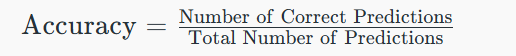

◈ 2. Precision :

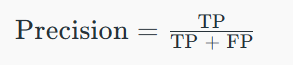

◈ 3. Recall :

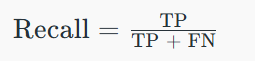

◈ 4. F1 Score :

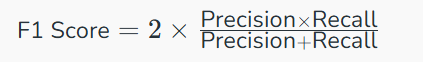

◈ 5. Logarithmic Loss (Log Loss) :

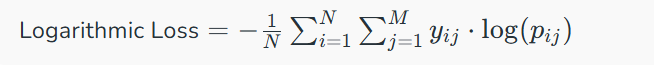

◈ 6(a). Area Under Curve (AUC) and ROC Curve :

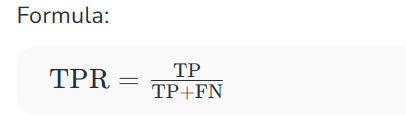

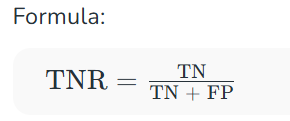

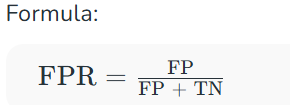

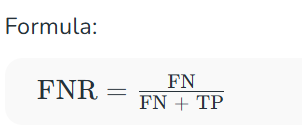

◈ 6(b) ROC(Receiver Operating Characteristic) Curve :

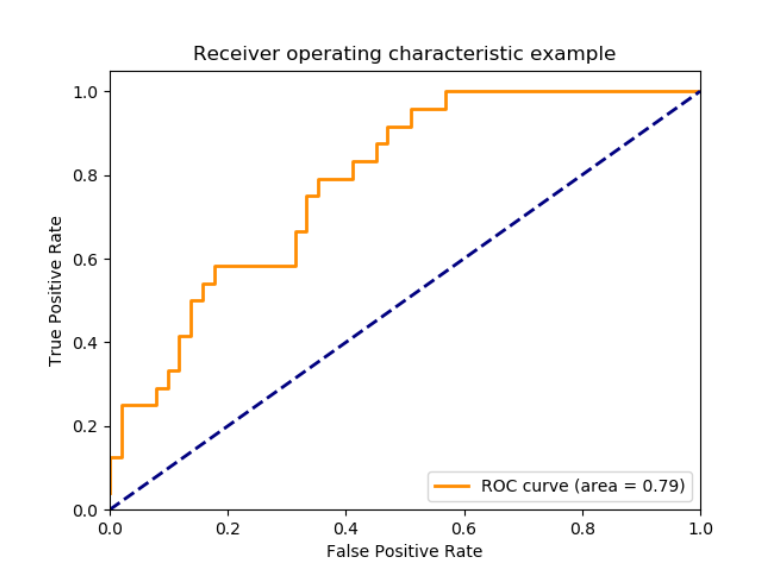

◈ 7. Confusion Matrix :

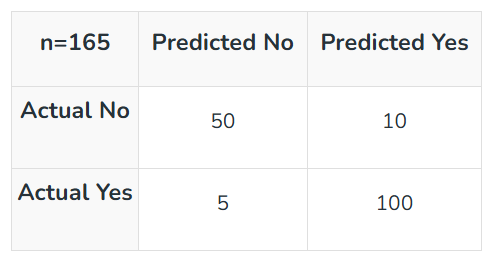

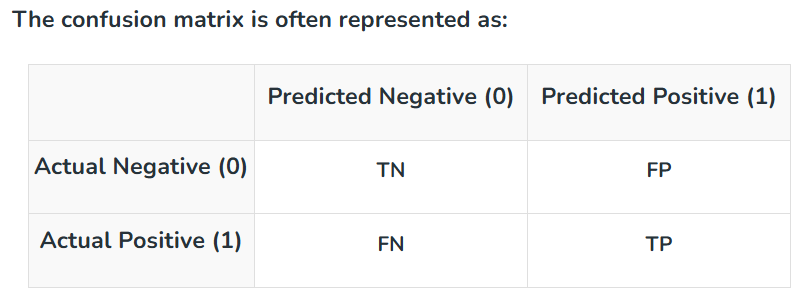

In [12]:
# Import Necessary Libraries
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score, roc_curve, auc, classification_report

# Make Predictions
# True labels
y_true = [0, 1, 1, 0, 1, 0, 0, 1, 1, 0]  # Actual classes
# Predicted labels
y_pred = [0, 1, 0, 0, 1, 1, 0, 1, 1, 1]  # Model predictions

# Calculating metrics
conf_matrix = confusion_matrix(y_true, y_pred)

accuracy = accuracy_score(y_true, y_pred)

precision = precision_score(y_true, y_pred)

recall = recall_score(y_true, y_pred)

f1 = f1_score(y_true, y_pred)

fpr, tpr, thresholds = roc_curve(y_true, y_pred)
roc_auc = auc(fpr, tpr)

print(f"Confusion Matrix:\n{conf_matrix}")
print(f"\nAccuracy: {accuracy}")
print(f"Precision: {precision}")
print(f"Recall: {recall}")
print(f"F1-Score: {f1}")
print(f"ROC AUC: {roc_auc}")

# Comprehensive report
print("\nClassification Report:")
print(classification_report(y_true, y_pred))


Confusion Matrix:
[[3 2]
 [1 4]]

Accuracy: 0.7
Precision: 0.6666666666666666
Recall: 0.8
F1-Score: 0.7272727272727272
ROC AUC: 0.7000000000000001

Classification Report:
              precision    recall  f1-score   support

           0       0.75      0.60      0.67         5
           1       0.67      0.80      0.73         5

    accuracy                           0.70        10
   macro avg       0.71      0.70      0.70        10
weighted avg       0.71      0.70      0.70        10



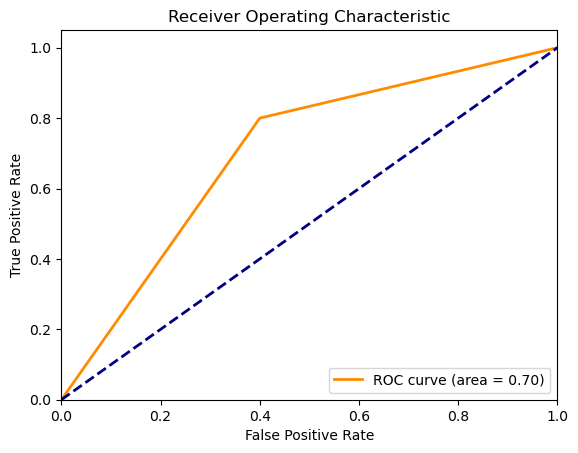

In [13]:
import matplotlib.pyplot as plt

# Plot ROC curve
plt.figure()

# Plot the ROC curve with a label displaying the ROC AUC score
plt.plot(fpr, tpr, color='darkorange', lw=2,
         label='ROC curve (area = %0.2f)' % roc_auc)

# Plot a dashed diagonal line for reference
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')

# Set the x and y-axis limits
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])

# Label the x and y-axes
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')

# Set the title of the plot
plt.title('Receiver Operating Characteristic')

# Add a legend to the plot
plt.legend(loc='lower right')

# Display the ROC curve plot
plt.show()

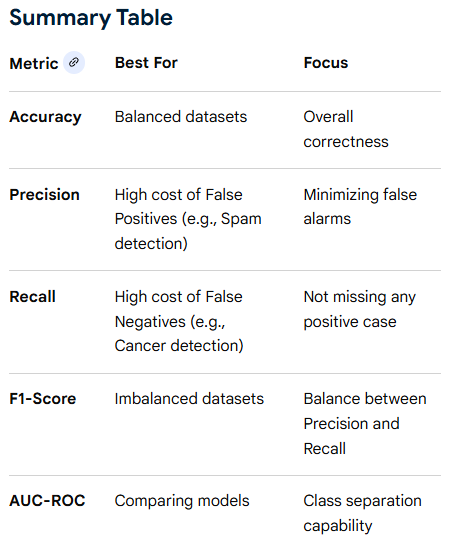

# 🔸Regression Metrics (7 key metrics)

◈ 1. Mean Absolute Error (MAE) :

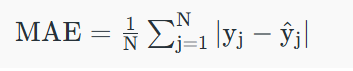

In [1]:
from sklearn.metrics import mean_absolute_error
from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

data = load_diabetes()

X = data.data
y = data.target

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = LinearRegression()

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)

print("MAE:", mae)

MAE: 42.79389304196524


◈ 2. Mean Squared Error (MSE) :

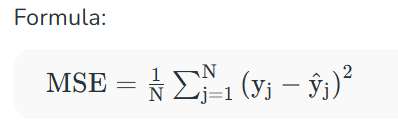

In [2]:
from sklearn.metrics import mean_squared_error

mse = mean_squared_error(y_test, y_pred)

print("MSE:", mse)

MSE: 2900.17328788323


◈ 3. Root Mean Squared Error (RMSE) :

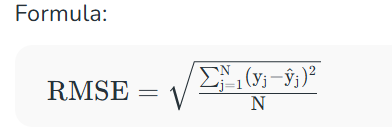

In [3]:
import numpy as np
from sklearn.metrics import mean_squared_error

rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("RMSE:", rmse)

RMSE: 53.85325698491438


◈ 4. Root Mean Squared Logarithmic Error (RMSLE) :

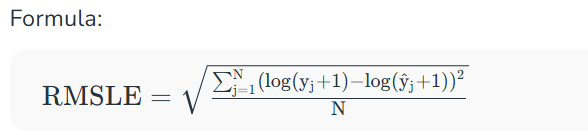

In [7]:
import numpy as np
from sklearn.metrics import mean_squared_log_error

def calculate_rmsle(y_true, y_pred):
    """
    Calculates RMSLE using numpy for vectorized operations.
    Formula: sqrt(mean((log(p+1) - log(a+1))^2))
    """
    return np.sqrt(np.mean((np.log1p(y_pred) - np.log1p(y_true))**2))

# Example Data
actual = np.array([100, 200, 300, 400, 500])
predicted = np.array([110, 190, 320, 380, 550])

# --- Method 1: Custom Function (NumPy) ---
rmsle_val = calculate_rmsle(actual, predicted)
print(f"RMSLE (Custom Function): {rmsle_val:.5f}")

# --- Method 2: Scikit-learn ---
# Note: mean_squared_log_error computes MSLE, so we take sqrt
msle = mean_squared_log_error(actual, predicted)
rmsle_sklearn = np.sqrt(msle)
print(f"RMSLE (Scikit-Learn):    {rmsle_sklearn:.5f}")


RMSLE (Custom Function): 0.07392
RMSLE (Scikit-Learn):    0.07392


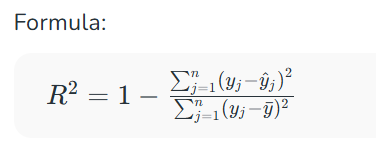

In [5]:
from sklearn.metrics import r2_score

r2 = r2_score(y_test, y_pred)

print("R² Score:", r2)

R² Score: 0.4526066021617383


◈ 6. Adjusted R-Squared :

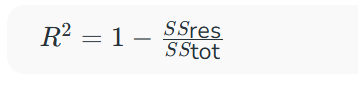

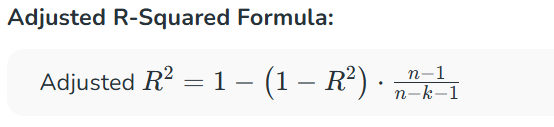

In [8]:
import statsmodels.api as sm
import pandas as pd

# Sample data
data = {
    'Hours_Studied': [2, 3, 4, 5, 6],
    'Attendance': [80, 85, 88, 90, 95],
    'Final_Score': [70, 75, 78, 85, 90]
}

df = pd.DataFrame(data)

X = df[['Hours_Studied', 'Attendance']]
X = sm.add_constant(X)  # adds the intercept

y = df['Final_Score']

model = sm.OLS(y, X).fit()

print("R-squared:", model.rsquared)
print("Adjusted R-squared:", model.rsquared_adj)

R-squared: 0.9882979345854543
Adjusted R-squared: 0.9765958691709087


◈ 7. Mean Absolute Percentage Error (MAPE) :

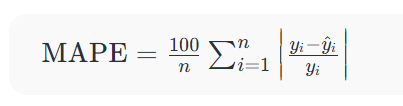

In [6]:
import numpy as np

mape = np.mean(np.abs((y_test - y_pred) / y_test)) * 100
print("MAPE:", mape)

MAPE: 37.49981253089933


# 🔸Clustering Metrics

◈ 1. Silhouette Score :

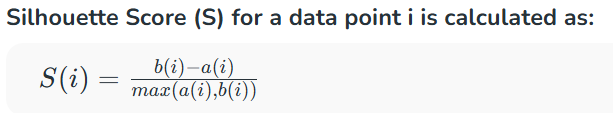

◈ 2. Davies-Bouldin Index :

In [ ]:
A lower score is better, because it means:

● Points in the same cluster are close to each other.
● Different clusters are far apart from one another.

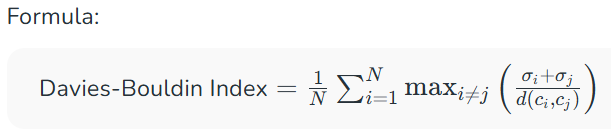

◈ 3. Calinski-Harabasz Index (Variance Ratio Criterion):

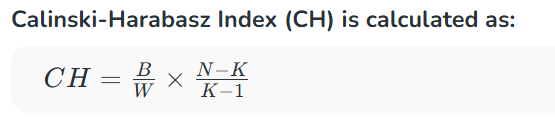

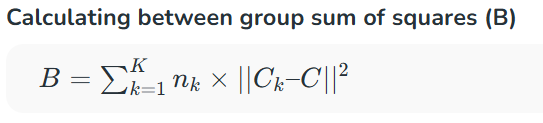

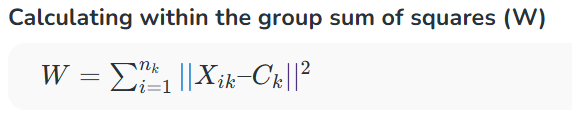

◈ 4. Adjusted Rand Index (ARI):

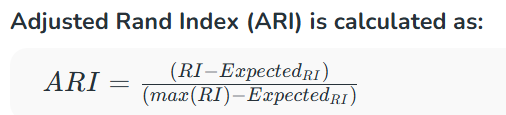

◈ 5. Mutual Information (MI):

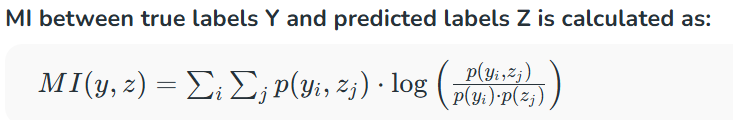

In [15]:
# Import Libraries
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
from sklearn.metrics import mutual_info_score, adjusted_rand_score

# Load Your Data
# Example using a built-in dataset (e.g., Iris dataset)
from sklearn.datasets import load_iris
iris = load_iris()
X = iris.data

# Perform Clustering
kmeans = KMeans(n_clusters=3)
kmeans.fit(X)

# Calculate Clustering Metrics
silhouette = silhouette_score(X, kmeans.labels_)
db_index = davies_bouldin_score(X, kmeans.labels_)
ch_index = calinski_harabasz_score(X, kmeans.labels_)
ari = adjusted_rand_score(iris.target, kmeans.labels_)
mi = mutual_info_score(iris.target, kmeans.labels_)

# Print the Metric Scores
print(f"Silhouette Score: {silhouette:.2f}")
print(f"Davies-Bouldin Index: {db_index:.2f}")
print(f"Calinski-Harabasz Index: {ch_index:.2f}")
print(f"Adjusted Rand Index: {ari:.2f}")
print(f"Mutual Information (MI): {mi:.2f}")

Silhouette Score: 0.55
Davies-Bouldin Index: 0.66
Calinski-Harabasz Index: 561.63
Adjusted Rand Index: 0.73
Mutual Information (MI): 0.83
